# 🔑 Setting Up Your Copernicus Data Store (CDS) API Token

When using the **Copernicus Data Store (CDS)** or **Atmosphere Data Store (ADS)** with the `cdsapi` Python client, you must authenticate using a **personal access token**.  
Without it, you’ll see errors like:
```
HTTPError: 404 Client Error: Not Found for url: https://cds.climate.copernicus.eu/api/retrieve/v1/processes/…
dataset not found
```
This happens when the client cannot find your CDS token or is pointing to the wrong endpoint.

---

## 1. Get Your Personal Access Token

1. Go to the appropriate data store:
   - 🌍 **CDS:** [https://cds.climate.copernicus.eu](https://cds.climate.copernicus.eu)
   - ☁️ **ADS (CAMS data):** [https://ads.atmosphere.copernicus.eu](https://ads.atmosphere.copernicus.eu)

2. Log in with your account.

3. Click your name in the top-right corner → **Profile** → scroll down to find your **API key** (also called *Personal Access Token*).

---

## 2. Create or Update the `.cdsapirc` File

Create a file named `.cdsapirc` in your **home directory** (e.g., `/home/jovyan/.cdsapirc` ).

Paste the following content:

For CDS:
```yaml
url: https://cds.climate.copernicus.eu/api
key: <YOUR-PERSONAL-ACCESS-TOKEN>
```
For ADS (CAMS data):

```yaml
url: https://ads.atmosphere.copernicus.eu/api
key: <YOUR-PERSONAL-ACCESS-TOKEN>
```

#!chmod 600 ~/.cdsapirc

## 3. download
**for cams, not working**
```
import cdsapi

dataset = "cams-global-reanalysis-eac4"
request = {
    "variable": ["total_column_ozone"],
    "date": ["2024-12-31/2024-12-31"],
    "time": ["00:00"],
    "grid": "N128",
    "data_format": "grib"
}

client = cdsapi.Client()
client.retrieve(dataset, request).download()
```

# Load the data in lat/lon

In [1]:
#!/usr/bin/env python
import cdsapi
import xarray as xr

try:
    ds = xr.open_dataset("output025.grib")
except:
    c = cdsapi.Client()
    
    c.retrieve("reanalysis-era5-complete", {
        "class": "ea",
        "date": "2025-01-01",
        "expver": "1",
        "levtype": "sfc",
        "number": "0/1/2/3/4/5/6/7/8/9",
        "param": "167.128",
        "step": "12",
        "stream": "enda",
        "time": "09:00:00",
        "type": "4v",
        "grid": "0.25/0.25"
    }, "output025.grib")
    c.retrieve("reanalysis-era5-complete", {
        "class": "ea",
        "date": "2025-01-01",
        "expver": "1",
        "levtype": "sfc",
        "number": "0/1/2/3/4/5/6/7/8/9",
        "param": "167.128",
        "step": "12",
        "stream": "enda",
        "time": "09:00:00",
        "type": "4v",
        "grid": "0.5/0.5"
    }, "output05.grib")
    c.retrieve("reanalysis-era5-complete", {
        "class": "ea",
        "date": "2025-01-01",
        "expver": "1",
        "levtype": "sfc",
        "number": "0/1/2/3/4/5/6/7/8/9",
        "param": "167.128",
        "step": "12",
        "stream": "enda",
        "time": "09:00:00",
        "type": "4v",
        "grid": "1.0/1.0"
    }, "output10.grib")


Ignoring index file 'output025.grib.5b7b6.idx' older than GRIB file


# load the data in Gaussian grid

In [2]:
try:
    dsG = xr.open_dataset("outputGT2m.grib")
except:
    c = cdsapi.Client()
    
    c.retrieve("reanalysis-era5-complete", {
        "class": "ea",
        "date": "2025-01-01",
        "expver": "1",
        "levtype": "sfc",
        "number": "0/1/2/3/4/5/6/7/8/9",
        "param": "167.128",
        "step": "12",
        "stream": "enda",
        "time": "09:00:00",
        "type": "4v",
        "grid":"N256",
    }, "outputGT2m.grib")
    dsG = xr.open_dataset("outputGT2m.grib")
dsG

Ignoring index file 'outputGT2m.grib.5b7b6.idx' older than GRIB file


<xarray.Dataset> Size: 20MB
Dimensions:     (number: 10, values: 348528)
Coordinates:
  * number      (number) int64 80B 0 1 2 3 4 5 6 7 8 9
    time        datetime64[ns] 8B ...
    step        timedelta64[ns] 8B ...
    surface     float64 8B ...
    latitude    (values) float64 3MB ...
    longitude   (values) float64 3MB ...
    valid_time  datetime64[ns] 8B ...
Dimensions without coordinates: values
Data variables:
    t2m         (number, values) float32 14MB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-01-30T10:34 GRIB to CDM+CF via cfgrib-0.9.1...

In [3]:
import matplotlib.pyplot as plt
import healpix_geo as hg
import healpy as hp
import numpy as np

In [4]:
level=8
name="output025.grib"

ds = xr.open_dataset(name)
if name=="output025.grib":
    degree='0.25/0.25'
if name=="output05.grib":
    degree='0.5/0.5'
if name=="output10.grib":
    degree='1.0/1.0'

Ignoring index file 'output025.grib.5b7b6.idx' older than GRIB file


# compute the bi-cubic interpolation of the lat,lon grid

In [5]:
import torch
import torch.nn.functional as F

@torch.no_grad()
def sample_bicubic_t2m_batch0(
    t2m: torch.Tensor,          # [B, H, W]
    lat: torch.Tensor,          # [N]
    lon: torch.Tensor,          # [N]
    lat_grid: torch.Tensor,     # [H] (monotone)
    lon_grid: torch.Tensor,     # [W] (monotone)
    *,
    align_corners: bool = True, # True => mapping exact aux bords
    lon_wrap: bool = True       # wrap lon si hors domaine
) -> torch.Tensor:
    """
    Retourne values[N] = t2m[0] interpolé bi-cubique aux coordonnées (lat, lon).

    - Supporte lat_grid croissant ou décroissant.
    - Supporte lon_grid croissant (typique). Si lon_wrap=True, wrap dans l’intervalle.
    - Utilise grid_sample(bicubic), très optimisé.
    """
    assert t2m.ndim == 3, "t2m doit être [B,H,W]"
    B, H, W = t2m.shape
    assert H == lat_grid.numel() and W == lon_grid.numel(), "Grilles incohérentes"

    device = t2m.device
    dtype = t2m.dtype

    lat = lat.to(device=device, dtype=dtype)
    lon = lon.to(device=device, dtype=dtype)
    lat_grid = lat_grid.to(device=device, dtype=dtype)
    lon_grid = lon_grid.to(device=device, dtype=dtype)

    # --- gestion orientation latitude (croissant vs décroissant) ---
    lat_inc = (lat_grid[-1] > lat_grid[0])
    lat_min = lat_grid[0] if lat_inc else lat_grid[-1]
    lat_max = lat_grid[-1] if lat_inc else lat_grid[0]

    # --- gestion longitude + wrap optionnel ---
    lon_min = lon_grid[0]
    lon_max = lon_grid[-1]
    if lon_wrap:
        # ramène lon dans [lon_min, lon_max] via modulo
        span = lon_max - lon_min
        # évite division par 0 si W==1
        if span != 0:
            lon = (lon - lon_min) % span + lon_min

    # --- normalisation vers coordonnées [-1, 1] attendues par grid_sample ---
    # grid_sample attend x = colonne (lon), y = ligne (lat)
    # Si align_corners=True: -1 -> index 0, +1 -> index W-1/H-1
    eps = torch.finfo(dtype).eps

    # clamp lat/lon dans le domaine (sinon padding_mode="border" gère, mais clamp évite NaN si span=0)
    latc = lat.clamp(min=lat_min - eps, max=lat_max + eps)
    lonc = lon.clamp(min=lon_min - eps, max=lon_max + eps)

    # y_norm
    y = (latc - lat_min) / (lat_max - lat_min + eps)  # [0,1] si lat_inc
    if not lat_inc:
        # si lat_grid décroissant, l'index 0 correspond à lat_max
        y = 1.0 - y
    y_norm = y * 2.0 - 1.0

    # x_norm
    x = (lonc - lon_min) / (lon_max - lon_min + eps)
    x_norm = x * 2.0 - 1.0

    # --- construire grid pour N points: shape [1, 1, N, 2] ---
    grid = torch.stack([x_norm, y_norm], dim=-1)          # [N,2]
    grid = grid.view(1, 1, -1, 2).to(dtype=dtype)

    # --- préparer l'image: [1, C=1, H, W] pour batch0 ---
    img = t2m[0].unsqueeze(0).unsqueeze(0)                # [1,1,H,W]

    # --- échantillonnage ---
    out = F.grid_sample(
        img, grid,
        mode="bicubic",
        padding_mode="border",   # extrapolation: prend la valeur au bord
        align_corners=align_corners
    )  # [1,1,1,N]

    return out.view(-1)  # [N]


In [6]:
dtype=torch.float64
device='cuda'
vals = sample_bicubic_t2m_batch0(torch.tensor(ds.t2m.values,dtype=dtype,device=device),
                                 torch.tensor(dsG.latitude.values, dtype=dtype,device=device),
                                 torch.tensor(dsG.longitude.values,dtype=dtype,device=device),
                                 torch.tensor(ds.latitude.values,dtype=dtype,device=device),
                                 torch.tensor(ds.longitude.values, dtype=dtype,device=device),
                                )


plt.figure(figsize=(16,4))
plt.subplot(1,3,1)
plt.scatter(dsG.longitude.values,dsG.latitude.values,c=dsG.t2m[0].values,s=1)
plt.subplot(1,3,2)
plt.scatter(dsG.longitude.values,dsG.latitude.values,c=vals.cpu().numpy(),s=1)
plt.subplot(1,3,3)
plt.scatter(dsG.longitude.values,dsG.latitude.values,c=np.log10(abs(vals.cpu().numpy()-dsG.t2m[0].values)),s=1)
plt.colorbar(shrink=0.5)

print('Ratio Lat/lon',ds.t2m[0].values.shape[0]*ds.t2m[0].values.shape[1]/dsG.t2m[0].values.shape[0])

Ratio Lat/lon 2.9789285222421156


# Compute weights for the ERA5 regridding

## Purpose

Compute, for each **HEALPix (NESTED) pixel center** at a target resolution, the **K nearest points** from an input **Gaussian grid** (e.g., ECMWF), using a **GPU-accelerated exact search**.

The method avoids global brute force by exploiting the **HEALPix quad-tree hierarchy** and **vectorized GPU distance evaluation**.

---

## Core Idea

### Spatial restriction with a coarse HEALPix index
1. Project all Gaussian points onto a **coarse HEALPix grid** (`level_coarse`).
2. For each coarse pixel, build a **candidate set** of Gaussian points from:
   - the coarse pixel itself
   - its 8 neighbors (`hp.get_all_neighbours`)
3. Process all fine-resolution children of the coarse pixel **in one GPU batch**.

### Fast exact distances on the sphere
Represent points as **unit vectors** in 3D. For unit vectors `a` and `b`:

$||a - b||^2 = 2 - 2 * (a · b)$


Distances become a matrix product + top-k:

- `dots = vh @ vg.T`
- `dist2 = 2 - 2*dots`
- `topk(dist2)` gives the K nearest Gaussian points.

---

## Why It’s Fast

- **NESTED contiguity**: children of a coarse pixel form a **contiguous block** at finer levels.
- The expensive step is a GPU GEMM per coarse pixel, not a global search.
- Complexity reduces from `O(N_heal * N_gauss)` to roughly `O(N_coarse * N_child * N_candidates)`.

---

## Main Components

### `HealpixKNNConfig`
Configuration for resolution, KNN, and GPU settings.

Key fields:
- `level`: target HEALPix level
- `level_coarse`: coarse level used for candidate restriction (`<= level`)
- `n_neighbors`: K
- `device`: usually `"cuda"`
- `dtype`: typically `float32`
- `max_candidates` (optional): cap neighborhood candidates to avoid extreme density cases

### `_latlon_to_unitvec_n3(lat, lon) -> (N,3)`
Convert Gaussian lat/lon (degrees) to unit vectors with guaranteed shape `(N,3)`.

### `_pix_to_unitvec_n3(nside, ipix, nest=True) -> (N,3)`
Convert HEALPix pixel indices to unit vectors (pixel centers), shape `(N,3)`.

### `build_healpix_gauss_knn(...)`
Main function returning:
- `knn_idx`: `(N_heal, K)` Gaussian indices
- `knn_dist2` (optional): `(N_heal, K)` squared distances

Algorithm steps:
1. Gaussian vectors `(Ng,3)` (CPU→GPU)
2. HEALPix fine vectors `(Nheal,3)` (GPU)
3. Assign Gaussian points to coarse pixels
4. Precompute coarse neighbors
5. Loop over coarse pixels:
   - gather candidates
   - load child HEALPix block
   - compute `dist2` on GPU
   - `topk` → fill outputs

---

## Recommended Settings

Typical starting point:

| target `level` | suggested `level_coarse` |
|---:|---:|
| 7 | 4–5 |
| 8 | 5–6 |
| 9 | 6–7 |

Notes:
- Increasing `level_coarse` reduces candidates (faster, less memory).
- `max_candidates` can be used as a safety valve (e.g., 5000–20000).

---

## Output Semantics

- `knn_idx[i, :]` are indices into the original Gaussian point list.
- `knn_dist2[i, :]` are exact squared distances on the unit sphere.
- Pixels with no candidates remain filled with `-1` (and `inf` for distances if requested).

---

## Summary

This approach provides **exact KNN on the sphere**, scalable to large grids, by combining:
- HEALPix hierarchy (coarse-to-fine restriction)
- NESTED memory contiguity (batch children)
- GPU matrix multiplication + top-k (fast exact distances)


In [7]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Optional, Tuple

import healpy as hp
import numpy as np
import torch


@dataclass(frozen=True)
class HealpixKNNConfig:
    level: int
    level_coarse: int
    n_neighbors: int
    device: str = "cuda"
    dtype: torch.dtype = torch.float32
    max_candidates: Optional[int] = None  # Optional safety cap per coarse pixel


def _latlon_to_unitvec_n3(lat_deg: np.ndarray, lon_deg: np.ndarray) -> np.ndarray:
    """Return unit vectors with shape (N, 3) from lat/lon in degrees."""
    lat_deg = np.asarray(lat_deg)
    lon_deg = np.asarray(lon_deg)
    theta = np.deg2rad(90.0 - lat_deg)  # colatitude
    phi = np.deg2rad(lon_deg)

    # healpy.ang2vec returns (x, y, z) each shaped (N,)
    v = hp.ang2vec(theta, phi).astype(np.float32, copy=False)  # (N,3)
    return v


def _pix_to_unitvec_n3(nside: int, ipix: np.ndarray, nest: bool) -> np.ndarray:
    """Return unit vectors with shape (N, 3) from HEALPix pixel indices."""
    ipix = np.asarray(ipix)
    x, y, z = hp.pix2vec(nside, ipix, nest=nest)
    v = np.stack([x, y, z], axis=1).astype(np.float32, copy=False)  # (N,3)
    return v


def build_healpix_gauss_knn(
    lat_gauss_deg: np.ndarray,
    lon_gauss_deg: np.ndarray,
    cfg: HealpixKNNConfig,
    return_dist2: bool = False,
) -> Tuple[np.ndarray, Optional[np.ndarray]]:
    """
    Compute KNN from each HEALPix pixel center (fine grid) to Gaussian points.

    The algorithm exploits NESTED contiguity:
    - Each coarse pixel corresponds to a contiguous block of fine pixels.
    - For each coarse pixel, we only compare its fine children against candidates
      from the coarse pixel neighborhood (itself + 8 neighbors).

    Heavy computations are done on GPU using matrix multiplication and topk.
    """
    if cfg.level_coarse > cfg.level:
        raise ValueError("level_coarse must be <= level")
    if cfg.n_neighbors <= 0:
        raise ValueError("n_neighbors must be > 0")

    level = cfg.level
    level_coarse = cfg.level_coarse
    k = cfg.n_neighbors

    nside = 2**level
    nside_c = 2**level_coarse

    n_heal = 12 * (4**level)
    n_coarse = 12 * (4**level_coarse)

    # --- Gaussian unit vectors (CPU -> GPU) ---
    v_gauss_np = _latlon_to_unitvec_n3(lat_gauss_deg, lon_gauss_deg)  # (Ng,3)
    if v_gauss_np.ndim != 2 or v_gauss_np.shape[1] != 3:
        raise RuntimeError(f"v_gauss_np must be (N,3), got {v_gauss_np.shape}")

    v_gauss = torch.as_tensor(v_gauss_np, device=cfg.device, dtype=cfg.dtype)  # (Ng,3)

    # --- Fine HEALPix pixel center vectors (GPU) ---
    v_heal_np = _pix_to_unitvec_n3(nside, np.arange(n_heal), nest=True)  # (Nheal,3)
    v_heal = torch.as_tensor(v_heal_np, device=cfg.device, dtype=cfg.dtype)  # (Nheal,3)

    # --- Map Gaussian points to coarse HEALPix (CPU) ---
    ipix_gauss_c = hp.vec2pix(
        nside_c,
        v_gauss_np[:, 0],
        v_gauss_np[:, 1],
        v_gauss_np[:, 2],
        nest=True,
    ).astype(np.int64, copy=False)

    # bins[p] = list of gaussian indices that fall into coarse pixel p
    bins: list[list[int]] = [[] for _ in range(n_coarse)]
    for i, p in enumerate(ipix_gauss_c):
        bins[int(p)].append(i)

    # Precompute coarse neighbors (CPU): shape (n_coarse, 8)
    neighbors_c = np.empty((n_coarse, 8), dtype=np.int64)
    for p in range(n_coarse):
        neigh = hp.get_all_neighbours(nside_c, p, nest=True)
        neighbors_c[p, :] = neigh.astype(np.int64, copy=False)

    # Outputs
    knn_idx = torch.full((n_heal, k), -1, device=cfg.device, dtype=torch.int64)
    knn_dist2 = (
        torch.full((n_heal, k), float("inf"), device=cfg.device, dtype=torch.float32)
        if return_dist2
        else None
    )

    dlevel = level - level_coarse
    n_child = 4**dlevel  # number of fine pixels per coarse pixel in NESTED

    # Main loop over coarse pixels (typically small), vectorized over children on GPU
    for p in range(n_coarse):
        # Build candidate list from coarse neighborhood
        cand = bins[p].copy()
        for q in neighbors_c[p]:
            if q >= 0:
                cand.extend(bins[int(q)])

        if len(cand) == 0:
            continue

        # Optional cap to keep memory bounded
        if cfg.max_candidates is not None and len(cand) > cfg.max_candidates:
            # Prefilter on CPU by cosine similarity to the coarse pixel center
            vc = np.array(hp.pix2vec(nside_c, p, nest=True), dtype=np.float32)  # (3,)
            vg = v_gauss_np[cand]  # (M,3)
            score = vg @ vc  # (M,)
            keep = np.argpartition(-score, cfg.max_candidates - 1)[: cfg.max_candidates]
            cand = [cand[i] for i in keep]

        cand_t = torch.as_tensor(cand, device=cfg.device, dtype=torch.int64)
        vg = v_gauss.index_select(0, cand_t)  # (M,3)

        # Fine children block for this coarse pixel (contiguous in NESTED)
        start = p * n_child
        end = start + n_child
        vh = v_heal[start:end, :]  # (C,3)

        # Fail-fast shape checks (remove once stable)
        if vh.ndim != 2 or vh.shape[1] != 3:
            raise RuntimeError(f"vh must be (C,3), got {tuple(vh.shape)}")
        if vg.ndim != 2 or vg.shape[1] != 3:
            raise RuntimeError(f"vg must be (M,3), got {tuple(vg.shape)}")

        # Exact squared distance via dot product (unit vectors)
        # dist2 = 2 - 2*(vh @ vg^T)  -> shape (C,M)
        dots = vh @ vg.T
        dist2 = (2.0 - 2.0 * dots).to(torch.float32)

        top = torch.topk(dist2, k=k, largest=False, dim=1)
        idx_local = top.indices  # (C,k)

        knn_idx[start:end, :] = cand_t[idx_local]
        if knn_dist2 is not None:
            knn_dist2[start:end, :] = top.values

    knn_idx_cpu = knn_idx.detach().cpu().numpy()
    knn_dist2_cpu = knn_dist2.detach().cpu().numpy() if knn_dist2 is not None else None
    return knn_idx_cpu, knn_dist2_cpu


# compute the nearest N Gaussian grid points from each HEALPix cells 

In [8]:
Npt=9

cfg = HealpixKNNConfig(
    level=level,
    level_coarse=level-3,
    n_neighbors=Npt,
    device="cuda",
    max_candidates=20000,  # optional, can be None
)

knn_idx, knn_dist2 = build_healpix_gauss_knn(
    lat_gauss_deg=dsG.latitude.values,
    lon_gauss_deg=dsG.longitude.values,
    cfg=cfg,
    return_dist2=True,
)
heal_idx=np.repeat(np.arange(12*4**level),Npt).reshape(knn_idx.shape)

In [9]:
print('Ratio : ', dsG.latitude.values.shape[0],100*(12*4**level)/dsG.latitude.values.shape[0])

Ratio :  348528 225.6438507092687


In [10]:
w=np.exp(-knn_dist2*4**level)
w/=np.sum(w,1)[:,None]

it=np.concatenate([knn_idx.ravel()[None,:],heal_idx.ravel()[None,:]],0)

M = torch.sparse_coo_tensor(it, w.ravel(), size=(dsG.latitude.values.shape[0],12*4**level), device='cuda', dtype=torch.float64)
norm_trans=np.bincount(knn_idx.ravel(),w.ravel())

it=np.concatenate([heal_idx.ravel()[None,:],knn_idx.ravel()[None,:]],0)
MT = torch.sparse_coo_tensor(it, w.ravel()/norm_trans[knn_idx.ravel()],
                             size=(12*4**level,dsG.latitude.values.shape[0]), 
                             device='cuda', dtype=torch.float64).coalesce()
M = M.coalesce().to_sparse_csr().to('cuda')
MT = MT.coalesce().to_sparse_csr().to('cuda')

/tmp/ipykernel_14070/2459963027.py:13: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /pytorch/aten/src/ATen/SparseCsrTensorImpl.cpp:53.)
  M = M.coalesce().to_sparse_csr().to('cuda')


In [11]:
im=(torch.tensor(dsG.t2m[0].values, device='cuda', dtype=torch.float64)@M).cpu().numpy()

plt.figure(figsize=(16,6))
hp.mollview(im,flip='geo',nest=True,hold=False,sub=(1,2,2),title='Regridded Map')

rinit=(torch.tensor(im,device='cuda')@MT).cpu().numpy()
print('Residu ',np.sqrt(np.mean((rinit-dsG.t2m[0].values)**2)))

Residu  0.18289871116396014


In [12]:
@torch.no_grad()
def conjugate_gradient(
    A_mv: Callable[[torch.Tensor], torch.Tensor],
    b: torch.Tensor,
    x0: Optional[torch.Tensor] = None,
    max_iter: int = 200,
    tol: float = 1e-6,
) -> Tuple[torch.Tensor, Dict[str, torch.Tensor]]:
    """
    Solve A x = b with Conjugate Gradient where A is SPD, using only matvec A_mv(v).
    No autograd (uses torch.no_grad).

    Returns:
        x: solution
        info: dict with residual norms history, iterations
    """
    if x0 is None:
        x = torch.zeros_like(b)
    else:
        x = x0.clone()

    r = b - A_mv(x)          # residual
    p = r.clone()
    rs_old = torch.einsum('ik,ik->i',r,r)

    b_norm = torch.linalg.norm(b)
    if b_norm == 0:
        return x, {"residual_norms": torch.tensor([0.0], device=b.device, dtype=b.dtype),
                   "iters": torch.tensor(0, device=b.device)}

    residual_norms = [torch.sqrt(rs_old)]

    for k in range(max_iter):
        Ap = A_mv(p)
        denom = torch.einsum('ik,ik->i',p,Ap)
        if torch.max(denom.abs()) < 1e-30:
            break  # breakdown (shouldn't happen for SPD unless numerical issues)

        alpha = rs_old / denom
        x = x + torch.einsum('k,ki->ki',alpha,p)
        r = r - torch.einsum('k,ki->ki',alpha,Ap)
        rs_new = torch.einsum('ik,ik->i',r,r)

        residual_norms.append(torch.sqrt(rs_new))

        # stopping criterion: relative residual
        if torch.max(torch.sqrt(rs_new)) <= tol * b_norm:
            rs_old = rs_new
            break

        beta = rs_new / rs_old
        p = r + torch.einsum('k,ki->ki',beta,p)
        rs_old = rs_new
        print(rs_old)

    info = {
        "residual_norms": torch.stack(residual_norms),
        "iters": torch.tensor(len(residual_norms) - 1, device=b.device),
    }
    return x, info


@torch.no_grad()
def least_squares_cg(M,MT,y,x_ref,x0, max_iter = 200,tol = 1e-6,damp = 0.0):
    """
    Solve min || M x - y ||_2^2 using CG on normal equations:
        (M^T M + damp*I) x = M^T y
    without explicitly forming M^T M.

    Args:
        M: [N1, N2]
        y: [N1]
        damp: optional Tikhonov regularization (lambda), solves min ||Mx-y||^2 + damp||x||^2
    """
    # b = M^T y
    b = (y - x_ref@M) @ MT

    def A_mv(v: torch.Tensor) -> torch.Tensor:
        # (M^T M + damp I) v
        return (v@M) @ MT + damp * v

    x, info = conjugate_gradient(A_mv=A_mv, b=b, x0=x0, max_iter=max_iter, tol=tol)
    return x, info
device = "cuda" if torch.cuda.is_available() else "cpu"

dtype = torch.float64  # souvent mieux pour CG

In [23]:
%%time
im=(torch.tensor(dsG.t2m[0:1].values, device='cuda', dtype=torch.float64)@M).cpu().numpy()

x0 = torch.tensor(np.zeros([1,12*4**level]),device=device,dtype=dtype)
x_ref = torch.tensor(im,device=device,dtype=dtype)
y  = torch.tensor(dsG.t2m[0:1].values,device=device,dtype=dtype)
    
healpy_est,info = least_squares_cg(MT,M, y, x_ref,x0, max_iter=1000, tol=1e-8, damp=0.001*(level==7))
healpy_est=healpy_est[0]+x_ref[0]
im=im[0]

tensor([1315.1753], device='cuda:0', dtype=torch.float64)
tensor([374.5325], device='cuda:0', dtype=torch.float64)
tensor([86.1536], device='cuda:0', dtype=torch.float64)
tensor([33.3460], device='cuda:0', dtype=torch.float64)
tensor([16.1833], device='cuda:0', dtype=torch.float64)
tensor([6.9235], device='cuda:0', dtype=torch.float64)
tensor([2.9282], device='cuda:0', dtype=torch.float64)
tensor([1.1802], device='cuda:0', dtype=torch.float64)
tensor([0.5124], device='cuda:0', dtype=torch.float64)
tensor([0.2321], device='cuda:0', dtype=torch.float64)
tensor([0.1153], device='cuda:0', dtype=torch.float64)
tensor([0.0568], device='cuda:0', dtype=torch.float64)
tensor([0.0301], device='cuda:0', dtype=torch.float64)
tensor([0.0167], device='cuda:0', dtype=torch.float64)
tensor([0.0094], device='cuda:0', dtype=torch.float64)
tensor([0.0052], device='cuda:0', dtype=torch.float64)
tensor([0.0028], device='cuda:0', dtype=torch.float64)
tensor([0.0015], device='cuda:0', dtype=torch.float64)
te

In [24]:
plt.figure(figsize=(16,12))
hp.orthview(im,flip='geo',nest=True,hold=False,sub=(2,2,1),title='Raw Regridded Map',rot=[0,40],cmap='jet',norm='hist')
hp.orthview(healpy_est.cpu().numpy(),flip='geo',nest=True,hold=False,sub=(2,2,2),title='Iterative Regridded Map',rot=[0,40],cmap='jet',norm='hist')
hp.orthview(np.log10(abs(im-healpy_est.cpu().numpy())),flip='geo',nest=True,hold=False,sub=(2,2,3),title='Difference Raw - Iterative',rot=[0,0],cmap='jet')
plt.subplot(2,2,4)
plt.title('Gaussian grid')
plt.scatter(dsG.longitude.values,dsG.latitude.values,c=dsG.t2m[0].values,s=0.01,cmap='jet')
plt.colorbar()

r=(torch.tensor(healpy_est.cpu().numpy(),device='cuda')@MT).cpu().numpy()

print('Residu BEFORE ',np.sqrt(np.mean((rinit-dsG.t2m[0].values)**2)),ds.t2m[0].values.min(),ds.t2m[0].values.max())
print('Residu AFTER ',np.sqrt(np.mean((r-dsG.t2m[0].values)**2)),ds.t2m[0].values.min(),ds.t2m[0].values.max())

Residu BEFORE  0.18289871116396014 218.08858 313.41473
Residu AFTER  7.784165935008396e-06 218.08858 313.41473


In [25]:
rinit=(torch.tensor(im,device='cuda')@MT).cpu().numpy()

plt.figure(figsize=(16,12))
plt.subplot(2,1,1)
plt.plot(dsG.t2m[0,0:10000].values,color='b',lw=4,label='Gaussian Grid')
plt.plot(r[0:10000],color='r',label='Iterative regridding')
plt.legend(frameon=0)
plt.xlabel('pixels')
plt.ylabel('T2m [K]')
plt.subplot(2,1,2)
plt.plot(rinit[0:10000]-dsG.t2m[0,0:10000].values,color='black',label='Residu Gaussian - Raw')
plt.plot(r[0:10000]-dsG.t2m[0,0:10000].values,color='grey',label='Residu Gaussian - iterative')
plt.legend(frameon=0)
plt.xlabel('pixels')
plt.ylabel(r'$\Delta$T2m [K]')

Text(0, 0.5, '$\\Delta$T2m [K]')

In [28]:
plt.figure(figsize=(18,4))
plt.subplot(1,3,1)
plt.title('Raw regridding')
plt.scatter(dsG.longitude.values,dsG.latitude.values,c=np.log10(abs(rinit-dsG.t2m[0].values)),s=0.1,vmin=-12,vmax=1,cmap='jet')
plt.colorbar(shrink=0.5,label=r'$log10(\sigma)$')
plt.subplot(1,3,2)
plt.title('Iterative regridding')
plt.scatter(dsG.longitude.values,dsG.latitude.values,c=np.log10(abs(r-dsG.t2m[0].values)),s=0.1,vmin=-12,vmax=1,cmap='jet')
plt.colorbar(shrink=0.5,label=r'$log10(\sigma)$')
plt.subplot(1,3,3)
plt.title('ECMWF %s'%(degree))
plt.scatter(dsG.longitude.values,dsG.latitude.values,c=np.log10(abs(vals.cpu().numpy()-dsG.t2m[0].values)),s=0.1,vmin=-12,vmax=1,cmap='jet')
plt.colorbar(shrink=0.5,label=r'$log10(\sigma)$')

In [29]:
amp=2
hy,hx=np.histogram(np.log10(abs(rinit-dsG.t2m[0].values)),range=[-11,amp],bins=1001)
hy2,hx=np.histogram(np.log10(abs(r-dsG.t2m[0].values)),range=[-11,amp],bins=1001)
hy3,hx=np.histogram(np.log10(abs(vals.cpu().numpy()-dsG.t2m[0].values)),range=[-11,amp],bins=1001)
hy=np.cumsum(hy.astype('float'))
hy2=np.cumsum(hy2.astype('float'))
hy3=np.cumsum(hy3.astype('float'))
hy/=np.max(hy)
hy2/=np.max(hy2)
hy3/=np.max(hy3)
plt.title('Residu Level=%d R=%.0f%%,ECMWF %s R=%.0f%%'%(level,100*12*(4**level)/dsG.t2m.shape[1],degree,100*ds.t2m.shape[1]*ds.t2m.shape[2]/dsG.t2m.shape[1]))
plt.plot(10**((hx[1:]+hx[:-1])/2),r.shape[0]*(1.0-hy),color='b',label='Raw regridding')
plt.plot(10**((hx[1:]+hx[:-1])/2),r.shape[0]*(1.0-hy2),color='r',label='Itterative regridding')
plt.plot(10**((hx[1:]+hx[:-1])/2),r.shape[0]*(1.0-hy3),color='black',label='ECMWF %s'%(degree))
plt.legend(frameon=0)
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\Delta$T2m [K]')
plt.ylabel('Histogram [#pixels]')
plt.grid()

In [30]:
from __future__ import annotations
from typing import Callable, Dict, Optional, Tuple
import torch


@torch.no_grad()
def conjugate_gradient_batch(
    A_mv: Callable[[torch.Tensor], torch.Tensor],
    b: torch.Tensor,                    # (B, N)
    x0: Optional[torch.Tensor] = None,  # (B, N)
    max_iter: int = 200,
    tol: float = 1e-6,
    eps_breakdown: float = 1e-30,
    track_history: bool = True,
) -> Tuple[torch.Tensor, Dict[str, torch.Tensor]]:
    """
    Batched Conjugate Gradient for SPD systems: A x = b, where A_mv(v) computes A@v.
    Works on tensors shaped (B, N). Runs without autograd and is GPU-friendly.

    Returns:
        x: (B, N) solution
        info: dict with residual norms history and number of iterations
    """
    if b.ndim != 2:
        raise ValueError(f"b must be 2D (B,N), got shape {tuple(b.shape)}")

    if x0 is None:
        x = torch.zeros_like(b)
    else:
        x = x0.clone()

    # Initial residual r = b - A x
    r = b - A_mv(x)
    p = r.clone()

    # rs_old = <r, r> per batch item => shape (B,)
    rs_old = (r * r).sum(dim=1)

    # Use per-batch stopping thresholds to avoid global reductions
    b_norm = b.norm(dim=1)  # (B,)
    # Handle b == 0 per batch
    zero_b = b_norm == 0
    # tol criterion: ||r|| <= tol * ||b||  (per batch)
    thresh = tol * b_norm

    if track_history:
        residual_norms = [rs_old.sqrt()]
    else:
        residual_norms = None

    # Active mask to stop updating converged systems without branching per element
    active = ~zero_b

    it = 0
    for it in range(max_iter):
        # Early exit if everything converged
        if not active.any():
            break

        Ap = A_mv(p)

        # denom = <p, Ap> per batch => (B,)
        denom = (p * Ap).sum(dim=1)

        # Breakdown detection per batch (avoid costly max(abs()) global sync)
        # We only update where active & denom is safe
        safe = active & (denom.abs() > eps_breakdown)
        if not safe.any():
            break

        alpha = torch.zeros_like(rs_old)
        alpha[safe] = rs_old[safe] / denom[safe]  # (B,)

        # x = x + alpha[:,None] * p  (fused addcmul is typically faster)
        x = torch.addcmul(x, p, alpha[:, None])

        # r = r - alpha[:,None] * Ap
        r = torch.addcmul(r, Ap, (-alpha)[:, None])

        rs_new = (r * r).sum(dim=1)  # (B,)

        if track_history:
            residual_norms.append(rs_new.sqrt())

        # Update active mask: converged if ||r|| <= tol*||b||  (per batch)
        active = active & (rs_new.sqrt() > thresh)

        beta = torch.zeros_like(rs_old)
        beta[safe] = rs_new[safe] / rs_old[safe]

        # p = r + beta[:,None] * p
        p = torch.addcmul(r, p, beta[:, None])

        rs_old = rs_new
        print(rs_old)

    info: Dict[str, torch.Tensor] = {
        "iters": torch.tensor(it + 1 if max_iter > 0 else 0, device=b.device),
    }
    if track_history:
        info["residual_norms"] = torch.stack(residual_norms, dim=0)  # (iters+1, B)
    return x, info


@torch.no_grad()
def least_squares_cg_batch(
    M: torch.Tensor,
    MT: torch.Tensor,
    y: torch.Tensor,        # (B, N1)
    x_ref: torch.Tensor,    # (B, N2)
    x0: Optional[torch.Tensor] = None,  # (B, N2)
    max_iter: int = 200,
    tol: float = 1e-6,
    damp: float = 0.0,
    track_history: bool = True,
) -> Tuple[torch.Tensor, Dict[str, torch.Tensor]]:
    """
    Solve min || M x - y ||^2 + damp ||x||^2 via CG on normal equations:
        (M^T M + damp I) x = M^T y
    without explicitly forming M^T M.

    Shapes assume:
        x: (B, N2)
        y: (B, N1)
        M: (N2, N1)
        MT: (N1, N2)  (typically MT = M.T)
    """
    # b = M^T (y - M x_ref)  (keeps your original intent)
    resid0 = y - (x_ref @ M)          # (B, N1)
    b = resid0 @ MT                   # (B, N2)
    

    def A_mv(v: torch.Tensor) -> torch.Tensor:
        # v: (B, N) -> treat as (N, B) for sparse.mm
        u = torch.sparse.mm(MT, v.T)        # (N_mid, B)
        Av = torch.sparse.mm(M, u).T        # (B, N)
        return Av + damp*v
        
    x, info = conjugate_gradient_batch(
        A_mv=A_mv,
        b=b,
        x0=x0,
        max_iter=max_iter,
        tol=tol,
        track_history=track_history,
    )
    return x, info


In [31]:
%%time
nmap=4
om=np.random.randn(nmap,dsG.t2m.shape[1])
im=(torch.tensor(om, device='cuda', dtype=torch.float64)@M).cpu().numpy()
x0 = torch.tensor(np.zeros([nmap,12*4**level]),device=device,dtype=dtype)
x_ref = torch.tensor(im,device=device,dtype=dtype)
y  = torch.tensor(om,device=device,dtype=dtype)
    
healpy_est,info = least_squares_cg_batch(MT,M, y, x_ref,x0, max_iter=10, tol=7e-5, damp=0.3)
healpy_est+=x_ref

tensor([6113.2406, 6134.8988, 6086.2719, 6130.8931], device='cuda:0',
       dtype=torch.float64)
tensor([531.1432, 528.2826, 528.7154, 529.5601], device='cuda:0',
       dtype=torch.float64)
tensor([53.5875, 53.6680, 53.7836, 53.6447], device='cuda:0',
       dtype=torch.float64)
tensor([5.2124, 5.2413, 5.2519, 5.2463], device='cuda:0', dtype=torch.float64)
tensor([0.5058, 0.5098, 0.5091, 0.5107], device='cuda:0', dtype=torch.float64)
tensor([0.0516, 0.0523, 0.0520, 0.0523], device='cuda:0', dtype=torch.float64)
tensor([0.0053, 0.0054, 0.0053, 0.0054], device='cuda:0', dtype=torch.float64)
tensor([0.0005, 0.0006, 0.0005, 0.0006], device='cuda:0', dtype=torch.float64)
tensor([5.7249e-05, 5.9214e-05, 5.8812e-05, 5.8749e-05], device='cuda:0',
       dtype=torch.float64)
CPU times: user 740 ms, sys: 0 ns, total: 740 ms
Wall time: 737 ms


Text(0, 0.5, 'Time/images [ms]')

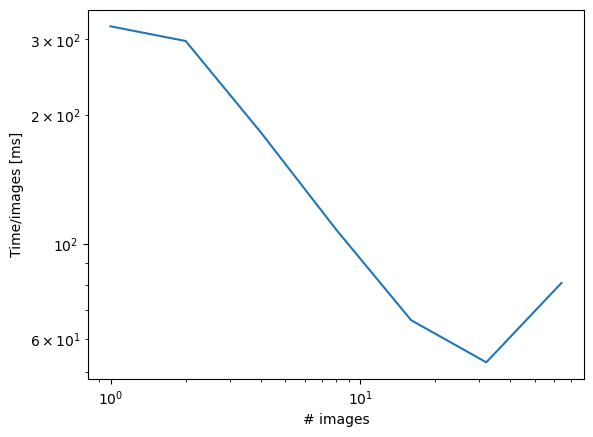

In [32]:
nim=np.array([1,2,4,8,16,32,64])
time=np.array([0.322,0.595,0.728,0.864,1.06,1.69,5.18])

plt.plot(nim,time/nim*1000)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('# images')
plt.ylabel('Time/images [ms]')

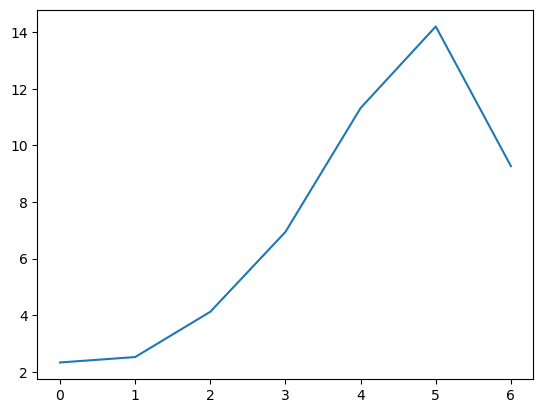

In [21]:
plt.plot(nim*12*4**level/(2**20)/time)